# Figure 5: MD simulations

Safe peptides vs activity cliffs, side by side.

**Layout:** 3 rows x 2 columns
- Row 1 (a, b): S-score distributions
- Row 2 (c, d): AUC heatmap across descriptors and simulation blocks
- Row 3 (e, f): ZP-score AUC, negative vs positive displacement bins

Left column = safe peptides (diverse active/inactive), right column = activity cliffs (paired peptides differing by few residues).

Data from Michal Sala's all-atom MD simulations (500 ns, DPPC bilayer, dual trajectories).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from sklearn.metrics import roc_auc_score
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

In [2]:
MD_DIR = Path("../md")

safe = pd.read_csv(MD_DIR / "safe" / "summary_aa_dual.csv")
paired = pd.read_csv(MD_DIR / "paired" / "summary_aa_dual.csv")

# Average the two trajectory samples (dn, up) per sequence/metric/step
safe_avg = safe.groupby(["sequence", "is_active", "metric", "step"])["value"].mean().reset_index()
paired_avg = paired.groupby(["sequence", "is_active", "metric", "step"])["value"].mean().reset_index()

print(f"Safe peptides: {safe_avg['sequence'].nunique()} sequences, "
      f"{safe_avg['metric'].nunique()} metrics")
print(f"Paired peptides: {paired_avg['sequence'].nunique()} sequences, "
      f"{paired_avg['metric'].nunique()} metrics")

Safe peptides: 36 sequences, 44 metrics
Paired peptides: 92 sequences, 44 metrics


In [5]:
# Journal specs: max 6.5 x 8 in, min fontsize 6, greyscale bg (25% tint),
# 2D charts, horizontal gridlines, 600 dpi for line/combo figures.

plt.rcParams.update({
    "font.size": 7,
    "axes.labelsize": 7,
    "axes.titlesize": 7.5,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6,
    "font.family": "sans-serif",
    "axes.facecolor": "#E0E0E0",
    "figure.facecolor": "white",
    "axes.edgecolor": "#666666",
    "axes.linewidth": 0.5,
    "xtick.major.width": 0.4,
    "ytick.major.width": 0.4,
    "xtick.major.size": 2,
    "ytick.major.size": 2,
    "axes.grid": False,
})

ACTIVE_COLOR = "#4878A8"
INACTIVE_COLOR = "#C06040"
STEPS = [1, 2, 3, 4, 5]

In [6]:
def plot_split_violins(ax, df, metric_col="S", ylabel="S-score", title=""):
    """Split violin plot: active vs inactive across simulation blocks."""
    data = df[df["metric"] == metric_col].copy()
    data["Status"] = data["is_active"].map({1: "Active", 0: "Inactive"})
    steps = sorted(data["step"].unique())

    for status, offset, color in [
        ("Active", -0.17, ACTIVE_COLOR),
        ("Inactive", 0.17, INACTIVE_COLOR),
    ]:
        subset = data[data["Status"] == status]
        data_by_step = [
            subset[subset["step"] == s]["value"].dropna().values for s in steps
        ]
        if all(len(d) == 0 for d in data_by_step):
            continue
        positions = np.array(steps) + offset
        vp = ax.violinplot(
            data_by_step, positions=positions,
            widths=0.3, showmedians=True, showextrema=False,
        )
        for body in vp["bodies"]:
            body.set_facecolor(color)
            body.set_alpha(0.65)
            body.set_edgecolor("black")
            body.set_linewidth(0.3)
            m = np.mean(body.get_paths()[0].vertices[:, 0])
            if offset < 0:
                body.get_paths()[0].vertices[:, 0] = np.clip(
                    body.get_paths()[0].vertices[:, 0], -np.inf, m)
            else:
                body.get_paths()[0].vertices[:, 0] = np.clip(
                    body.get_paths()[0].vertices[:, 0], m, np.inf)
        vp["cmedians"].set_color("black")
        vp["cmedians"].set_linewidth(0.5)

    for yval in np.arange(0, 1.1, 0.2):
        ax.axhline(y=yval, color="white", linewidth=0.4, zorder=0)

    ax.set_xticks(steps)
    ax.set_xticklabels([str(s) for s in steps])
    ax.set_xlabel("Simulation block (100 ns each)")
    ax.set_ylabel(ylabel)
    ax.set_title(title, loc="left", fontweight="bold")
    ax.set_xlim(0.4, 5.6)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)


def compute_auc_matrix(df, metrics, steps):
    """Compute AUC for each metric/step, direction-corrected."""
    matrix = np.full((len(steps), len(metrics)), np.nan)
    for j, metric in enumerate(metrics):
        for i, step in enumerate(steps):
            subset = df[(df["metric"] == metric) & (df["step"] == step)]
            if len(subset) < 5 or len(np.unique(subset["is_active"])) < 2:
                continue
            try:
                matrix[i, j] = roc_auc_score(
                    subset["is_active"].values, subset["value"].values)
            except Exception:
                pass
    # Direction-correct: if mean AUC < 0.5, flip
    for j in range(len(metrics)):
        col = matrix[:, j]
        valid = col[~np.isnan(col)]
        if len(valid) > 0 and np.mean(valid) < 0.5:
            matrix[:, j] = 1.0 - col
    return matrix


def plot_auc_heatmap(ax, matrix, metrics, steps, title="",
                     vmin=0.35, vmax=0.90, metric_labels=None):
    """AUC heatmap with cell annotations."""
    im = ax.imshow(
        matrix, cmap="RdYlGn", aspect="auto",
        vmin=vmin, vmax=vmax, interpolation="nearest",
    )
    for i in range(len(steps)):
        for j in range(len(metrics)):
            val = matrix[i, j]
            if not np.isnan(val):
                color = "white" if val > 0.82 or val < 0.42 else "black"
                ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                        fontsize=6, color=color)

    labels = metric_labels if metric_labels else metrics
    ax.set_xticks(range(len(metrics)))
    ax.set_xticklabels(labels, fontsize=6, ha="center", rotation=0)
    ax.set_yticks(range(len(steps)))
    ax.set_yticklabels([f"Block {s}" for s in steps])
    ax.set_title(title, loc="left", fontweight="bold")
    return im


def plot_zp_bars(ax, df, step, title="", show_legend=True):
    """Paired bar chart: ZP-negative vs ZP-positive AUC."""
    zp_neg = [f"ZP-{b}" for b in
              ["0.5", "1.5", "2.5", "3.5", "4.5",
               "5.5", "6.5", "7.5", "8.5", "9.5"]]
    zp_pos = [f"ZP{b}" for b in
              ["0.5", "1.5", "2.5", "3.5", "4.5",
               "5.5", "6.5", "7.5", "8.5", "9.5"]]

    def get_aucs(bins):
        aucs = []
        for metric in bins:
            subset = df[(df["metric"] == metric) & (df["step"] == step)]
            if len(subset) < 5 or len(np.unique(subset["is_active"])) < 2:
                aucs.append(np.nan)
                continue
            try:
                aucs.append(roc_auc_score(
                    subset["is_active"].values, subset["value"].values))
            except Exception:
                aucs.append(np.nan)
        return aucs

    aucs_neg = get_aucs(zp_neg)
    aucs_pos = get_aucs(zp_pos)

    x = np.arange(len(zp_neg))
    width = 0.35

    ax.bar(x - width / 2, aucs_neg, width, color=ACTIVE_COLOR, alpha=0.75,
           edgecolor="black", linewidth=0.3,
           label="ZP negative (membrane thinning)")
    ax.bar(x + width / 2, aucs_pos, width, color=INACTIVE_COLOR, alpha=0.75,
           edgecolor="black", linewidth=0.3,
           label="ZP positive (membrane thickening)")

    ax.axhline(y=0.5, color="black", linewidth=0.6, linestyle="--", alpha=0.6)
    for yval in [0.3, 0.4, 0.6, 0.7, 0.8]:
        ax.axhline(y=yval, color="white", linewidth=0.4, zorder=0)

    bin_values = [0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5, 9.5]
    ax.set_xticks(x)
    ax.set_xticklabels([f"{v:.1f}" for v in bin_values], fontsize=6)
    ax.set_xlabel("Phosphate displacement magnitude (\u00c5)")
    ax.set_ylabel("AUC")
    ax.set_ylim(0.15, 0.92)
    ax.set_title(title, loc="left", fontweight="bold")
    if show_legend:
        ax.legend(loc="upper left", frameon=True, facecolor="white",
                  edgecolor="none", framealpha=0.9, fontsize=6)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

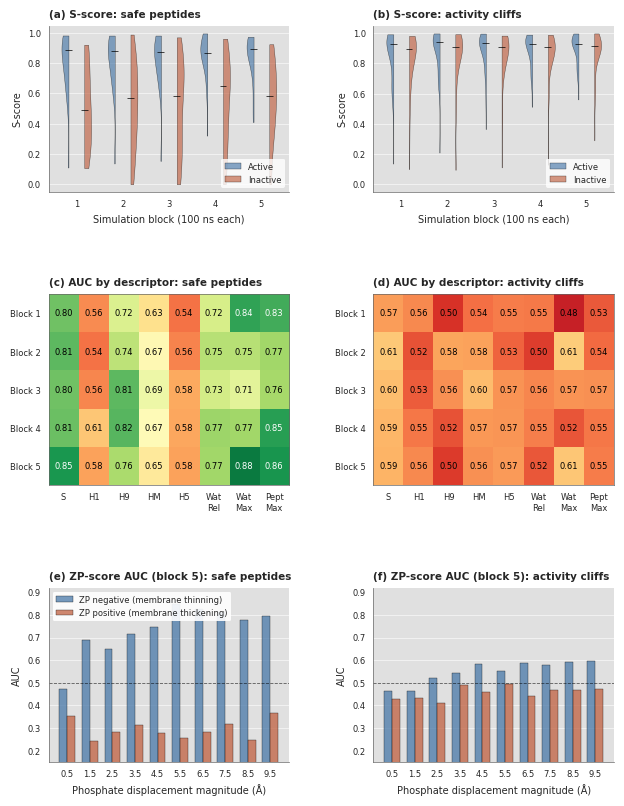

Saved to ../figures/figure5.png and .pdf


In [7]:
fig = plt.figure(figsize=(6.5, 8.0))
gs = gridspec.GridSpec(
    3, 2, hspace=0.58, wspace=0.35,
    left=0.09, right=0.96, top=0.97, bottom=0.05,
    height_ratios=[1, 1.15, 1.05],
)

LEGEND_HANDLES = [
    Patch(facecolor=ACTIVE_COLOR, alpha=0.65, edgecolor="black",
          linewidth=0.3, label="Active"),
    Patch(facecolor=INACTIVE_COLOR, alpha=0.65, edgecolor="black",
          linewidth=0.3, label="Inactive"),
]

# Row 1: S-score violins
ax_a = fig.add_subplot(gs[0, 0])
plot_split_violins(ax_a, safe_avg, "S", "S-score", "(a) S-score: safe peptides")
ax_a.legend(handles=LEGEND_HANDLES, loc="lower right",
            frameon=True, facecolor="white", edgecolor="none", framealpha=0.8)

ax_b = fig.add_subplot(gs[0, 1])
plot_split_violins(ax_b, paired_avg, "S", "S-score", "(b) S-score: activity cliffs")
ax_b.legend(handles=LEGEND_HANDLES, loc="lower right",
            frameon=True, facecolor="white", edgecolor="none", framealpha=0.8)

# Row 2: AUC heatmaps
h_metrics = ["S", "H1", "H9", "HM", "H5",
             "WAT_BUR_REL", "WAT_BUR_MAX", "PEPT_BUR_MAX"]
metric_labels = ["S", "H1", "H9", "HM", "H5", "Wat\nRel", "Wat\nMax", "Pept\nMax"]

safe_auc = compute_auc_matrix(safe_avg, h_metrics, STEPS)
paired_auc = compute_auc_matrix(paired_avg, h_metrics, STEPS)

all_vals = np.concatenate([
    safe_auc[~np.isnan(safe_auc)],
    paired_auc[~np.isnan(paired_auc)],
])
vmin_shared = max(0.35, np.floor(all_vals.min() * 20) / 20)
vmax_shared = min(0.92, np.ceil(all_vals.max() * 20) / 20)

ax_c = fig.add_subplot(gs[1, 0])
plot_auc_heatmap(ax_c, safe_auc, h_metrics, STEPS,
                 "(c) AUC by descriptor: safe peptides",
                 vmin=vmin_shared, vmax=vmax_shared,
                 metric_labels=metric_labels)

ax_d = fig.add_subplot(gs[1, 1])
plot_auc_heatmap(ax_d, paired_auc, h_metrics, STEPS,
                 "(d) AUC by descriptor: activity cliffs",
                 vmin=vmin_shared, vmax=vmax_shared,
                 metric_labels=metric_labels)

# Row 3: ZP-score bars
ax_e = fig.add_subplot(gs[2, 0])
plot_zp_bars(ax_e, safe_avg, step=5, title="(e) ZP-score AUC (block 5): safe peptides")

ax_f = fig.add_subplot(gs[2, 1])
plot_zp_bars(ax_f, paired_avg, step=5,
             title="(f) ZP-score AUC (block 5): activity cliffs",
             show_legend=False)

fig.savefig("../figures/figure5.png", dpi=600, bbox_inches="tight", facecolor="white")
fig.savefig("../figures/figure5.pdf", dpi=600, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved to ../figures/figure5.png and .pdf")